# FLIWBO Hyperparameter Visualization

This notebook gives visual intuition for the main FLIWBO hyperparameters using a tiny 1D objective with deliberately non-stationary behavior.

The point is not to benchmark anything. The point is to see how the fitted GP, selected Beta-CDF input warp, and finite warp library change as the optimizer knobs move.

In [1]:
from pathlib import Path
import os
import sys


def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "src" / "fliwbo_core").exists():
            return path
    raise RuntimeError("Could not find repository root containing src/fliwbo_core")


repo_root = find_repo_root(Path.cwd())
os.environ.setdefault("MPLCONFIGDIR", str(repo_root / ".matplotlib-cache"))
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "examples" / "notebooks"))

import matplotlib.pyplot as plt  # noqa: E402

from hyperparameter_visualization import (  # noqa: E402
    plot_epsilon_warp_panel,
    plot_lengthscale_panel,
    plot_noise_panel,
    plot_toy_data,
    plot_warp_regularization_panel,
)


plt.rcParams["figure.dpi"] = 120

## Toy Objective

The observed function changes slowly in some regions and quickly in others. That is the kind of shape where input warping can be useful: the optimizer can stretch or squeeze the input coordinate before fitting the GP.

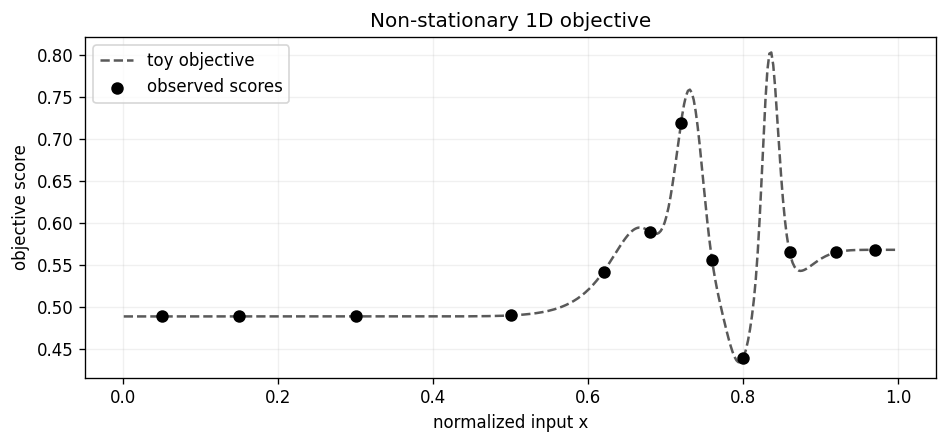

In [2]:
plot_toy_data();

## `lengthscale`

The lengthscale controls how far influence travels in the GP input space. Smaller values allow wigglier fits, larger values make the fit smoother.

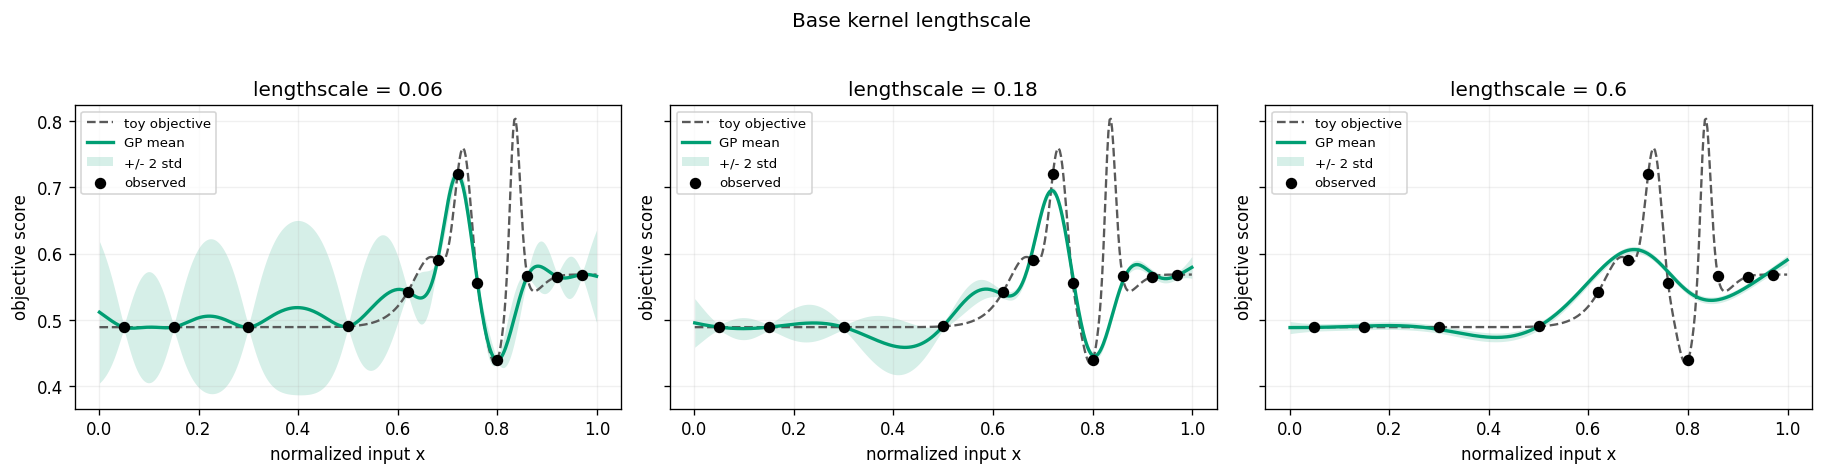

In [3]:
plot_lengthscale_panel();

## `noise_std`

The noise setting tells the GP how tightly to trust each observed score. Larger values make the model less pinned to individual observations.

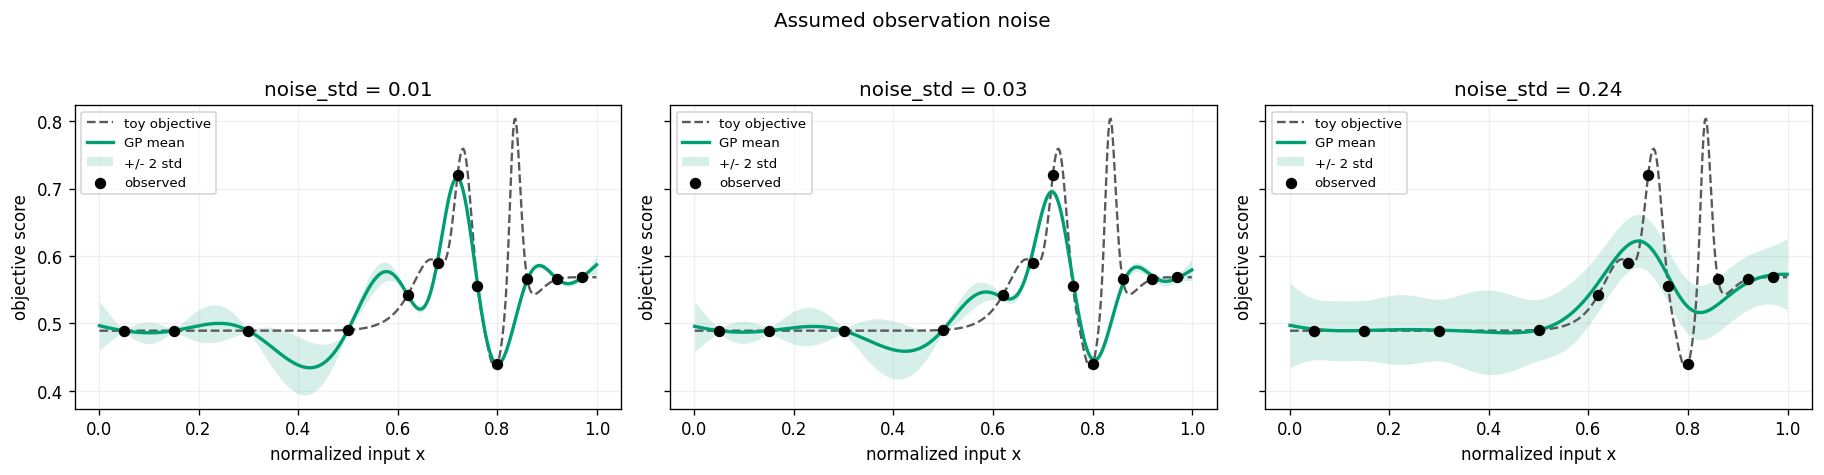

In [4]:
plot_noise_panel();

## Warp Regularization

This panel uses only a few sparse observations, like the early stage of an expensive BO run. With the prior off, the warp search can overcommit to an extreme explanation of thin data. A balanced prior keeps the model more cautious while evidence accumulates. Too much regularization keeps the warp close to unity and gives up the advantage of learning useful input geometry.

Treat `use_warp_prior`, `warp_prior_weight`, and `warp_prior_tau` as one regularization setting. The weight and tau are mathematically entangled, so tune them as a pair rather than as independent knobs.

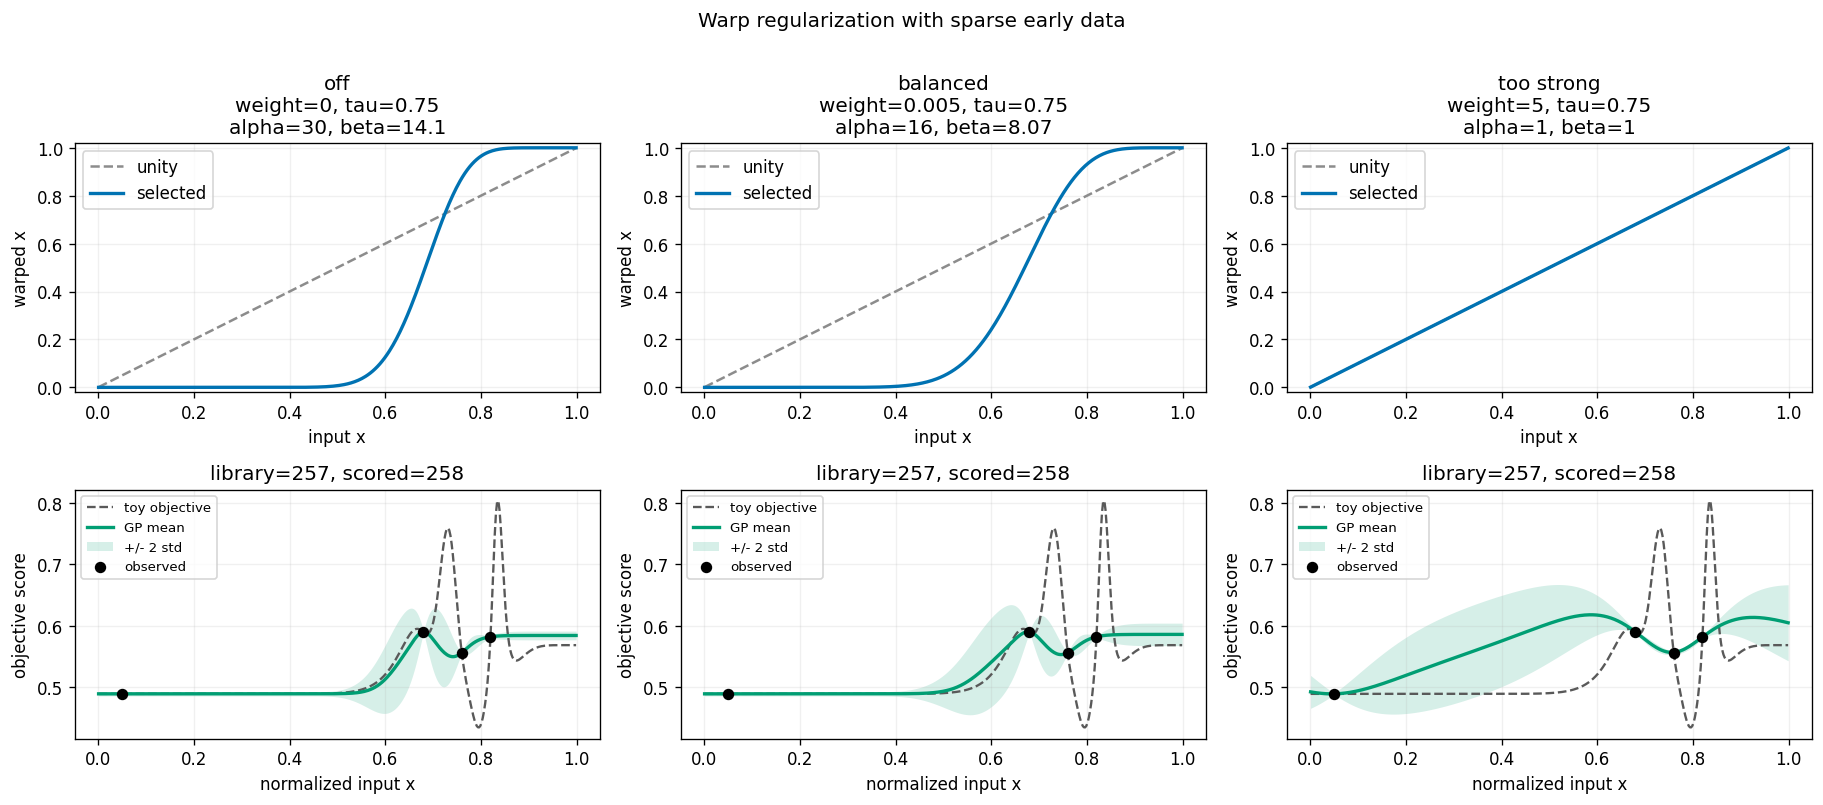

In [5]:
plot_warp_regularization_panel();

## `epsilon_warp`

Epsilon controls the finite warp-library resolution. A large epsilon gives the optimizer a sparse menu of possible Beta-CDF warps. A small epsilon gives a much denser menu, which is more expressive but costs more GP scoring work.

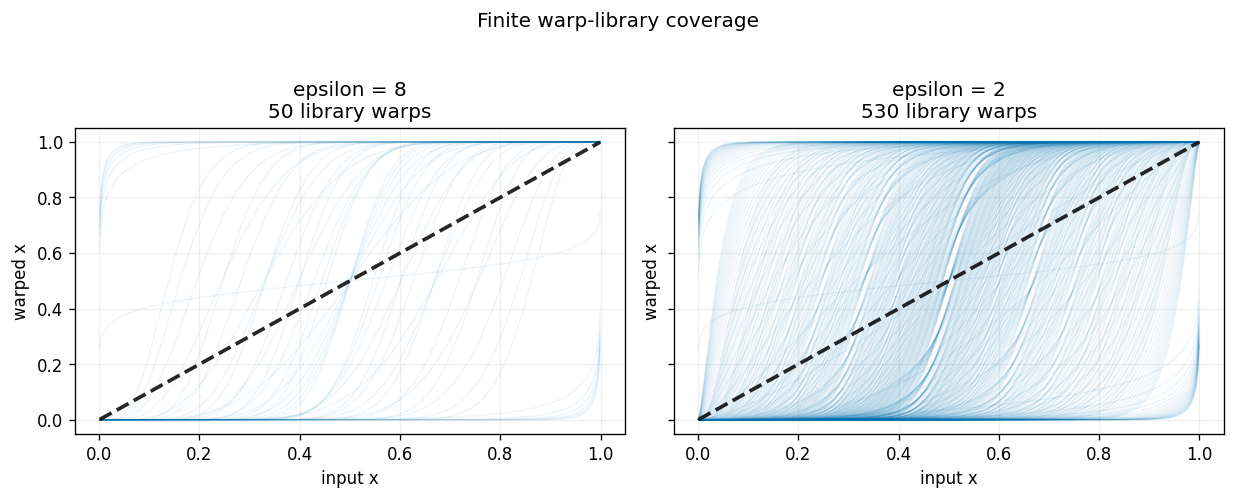

In [6]:
plot_epsilon_warp_panel();